In [1]:
import ipywidgets as widgets
from IPython.display import display

In [2]:
from utils.dataloader import AlgonautsLoader, HCPTRTLoader

import yaml

import numpy as np
import pandas as pd

from tqdm import tqdm

import nibabel as nib

/home/petron/AIMS/Thesis/TRACE_Algonauts/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


# Data Loading Test

In [3]:
algonauts_dataset = AlgonautsLoader(dataset='algonauts', split='train')
hcptrt_dataset = HCPTRTLoader(
    fmri_dir="data/cneuromod.processed/fmriprep/hcptrt/",
    subjects=[1],
    tr=1.49,
    hrf_delay=5,
    parcellation="mmp"
)

[fetch_atlas_schaefer_2018] Dataset found in /home/petron/nilearn_data/schaefer_2018
Parcellation : mmp — 379 regions (hcp_utils, no download needed)


### Algonauts

#### Get Stimuli Info +  Load Transcript

In [4]:
# @title Get Stimuli Info per subject

subject = 1

fmri_stimuli_info = algonauts_dataset.list_fmri_sessions(
    subject=subject,
    split='train'
)

In [ ]:
fmri_stimuli_info

In [6]:
fmri_stimuli_info[0][13:]

's01e02a'

In [7]:
# @title Load stimuli transcript

transcript_df = algonauts_dataset.load_transcript(
    stimuli_name=fmri_stimuli_info[0],
    split='train',
    ignore_nans=True
    )

transcript_df.shape

(366, 4)

In [8]:
transcript_df

,text_per_tr,words_per_tr,onsets_per_tr,durations_per_tr
0,You.,['You.'],[0.33],[0.55]
1,What you guys don't,"['What', 'you', 'guys', ""don't""]","[1.89, 2.228, 2.388, 2.612]","[0.316, 0.138, 0.186, 0.214]"
2,"understand is, for us,","['understand', 'is,', 'for', 'us,']","[2.858, 3.22, 3.556, 3.812]","[0.292, 0.282, 0.218, 0.586]"
3,kissing is as important,"['kissing', 'is', 'as', 'important']","[4.564, 5.098, 5.268, 5.428]","[0.502, 0.148, 0.138, 0.33]"
4,as any part of it.,"['as', 'any', 'part', 'of', 'it.']","[5.844, 6.068, 6.292, 6.468, 6.628]","[0.202, 0.186, 0.154, 0.138, 0.522]"
...,...,...,...,...
473,She's,"[""She's""]",[705.37],[0.68]
474,pregnant with my,"['pregnant', 'with', 'my']","[706.13, 706.706, 707.036]","[0.512, 0.276, 0.218]"
475,child.,['child.'],[707.292],[0.588]
476,And she and Susan are going,"['And', 'she', 'and', 'Susan', 'are', 'going']","[708.97, 709.436, 709.628, 709.788, 710.178, 7...","[0.412, 0.17, 0.138, 0.358, 0.196, 0.154]"


#### Load Algonauts Subject fMRI data per stimuli & subject atlas

In [9]:
# @title Load subject fMRI resposnes data for a specific stimuli

subject = 5

recording_session = '001'
season = '01'
episode = '02'
episode_split = 'b'

fmri_key = f'ses-{recording_session}_task-s{season}e{episode}{episode_split}'
print(f'stimuli+session: {fmri_key}')

file_name = "sub-01_task-friends_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5"
fmri_data = algonauts_dataset.load_fmri_responses(
    subject=subject,
    stimuli_name=fmri_key,
    split='train'
)
fmri_data.shape

stimuli+session: ses-001_task-s01e02b


(482, 1000)

In [10]:
# @title Fetah each subject's atlas info

subject1_atlas_coord, parcel_ids, parcel_desc = algonauts_dataset.load_atlas_for_subject(subject=1)
subject2_atlas_coord, parcel_ids, parcel_desc = algonauts_dataset.load_atlas_for_subject(subject=2)
subject3_atlas_coord, parcel_ids, parcel_desc = algonauts_dataset.load_atlas_for_subject(subject=3)
subject5_atlas_coord, parcel_ids, parcel_desc = algonauts_dataset.load_atlas_for_subject(subject=5)

(subject1_atlas_coord == subject5_atlas_coord).all()

np.True_

### HCPTRT

#### Test Data Loading and Events Epoching

In [12]:
events_df = hcptrt_dataset.load_events(
    subject='sub-01',
    session='ses-001',
    task='motor',
    run=1,
    bloc_only=False
)
events_df

,trial_type,nbloc,onset,duration,countdown_stim
0,countdown,NaN,0.000,1.984,4.0
1,countdown,NaN,1.999,1.985,3.0
2,countdown,NaN,3.999,1.985,2.0
3,countdown,NaN,5.999,1.985,1.0
4,new_bloc_left_hand,1.0,8.016,2.983,NaN
...,...,...,...,...,...
112,response_left_foot,22.0,184.192,0.164,NaN
113,response_left_foot,22.0,185.405,0.152,NaN
114,response_left_foot,22.0,186.608,0.164,NaN
115,response_left_foot,22.0,187.822,0.152,NaN


In [13]:
fmri_data = hcptrt_dataset.load_fmri_responses(
    subject='sub-01',
    session='ses-001',
    task='gambling',
    run=1,
    denoise=True,
    parcellate=True,
)

In [14]:
fmri_data.shape

(129, 379)

In [15]:
X, onsets, y = hcptrt_dataset.epoch_bold_by_blocks(
    fmri_data, 
    events_df
)

In [16]:
X.shape, onsets.shape, y.shape

((9, 10, 379), (9,), (9,))

In [17]:
y

array(['left_hand', 'right_foot', 'tongue', 'left_foot', 'right_hand',
       'left_hand', 'tongue', 'right_foot', 'right_hand'], dtype='<U10')

#### Atlas Info Loading

In [4]:
coords = hcptrt_dataset.get_atlas_info()

/home/petron/AIMS/Thesis/TRACE_Algonauts/utils/loaders/hcptrt.py:306: RuntimeWarning: Mean of empty slice
  centroid = np.nanmean(all_coords[mask], axis=0)   # NaN-safe for subcortical


In [5]:
coords.keys()

dict_keys(['parcel_ids', 'parcel_names', 'parcel_coords', 'parcel_desc'])

In [8]:
(coords['parcel_coords'])

array([[ 37.43433  , -55.626625 , -12.058883 ],
       [ 33.280323 , -63.345737 ,  36.17028  ],
       [ 34.56116  , -33.17576  ,  -3.0225205],
       ...,
       [  0.       ,   0.       ,   0.       ],
       [  0.       ,   0.       ,   0.       ],
       [  0.       ,   0.       ,   0.       ]],
      shape=(379, 3), dtype=float32)

## Subject Dataloading Test

### Algonauts

In [20]:
algonauts_dataset = AlgonautsLoader(dataset='algonauts', split='train')

[fetch_atlas_schaefer_2018] Dataset found in /home/petron/nilearn_data/schaefer_2018


#### Stimuli-Episodes fMRI Response

In [21]:
subject_dataset = algonauts_dataset.load_episode_fmri(subject)

Loading fMRI timeseries for s-05


  0%|          | 0/289 [00:00<?, ?it/s]

100%|██████████| 289/289 [00:03<00:00, 75.03it/s]


Loading parcel coordinates for s-05


In [ ]:
for stimuli_name in subject_dataset['scenes_response']:
    print(stimuli_name, subject_dataset['scenes_response'][stimuli_name].shape)

#### Word Epoched (Stimuli-Episodes) fMRI Response

In [23]:
subject_dataset = algonauts_dataset.load_episode_word_epochs(subject)

Loading word epochs for s-05


100%|██████████| 289/289 [00:23<00:00, 12.39it/s]


Loading parcel coordinates for s-05


In [24]:
subject_dataset.keys()

dict_keys(['scenes_response', 'parcel_coords', 'parcel_ids', 'parcel_desc'])

In [ ]:
subject_dataset['parcel_desc']

In [ ]:
for stimuli_name in subject_dataset['scenes_response'].keys():
    print(
        stimuli_name,
        subject_dataset['scenes_response'][stimuli_name]['trials'].shape, 
        (subject_dataset['scenes_response'][stimuli_name]['start'].shape, subject_dataset['scenes_response'][stimuli_name]['end'].shape)
        )

### HCPTRT

In [3]:
hcptrt_dataset = HCPTRTLoader(
    fmri_dir="data/cneuromod.processed/fmriprep/hcptrt/",
    subjects=[1],
    tr=1.49,
    hrf_delay=5,
    parcellation="mmp"
)

Parcellation : mmp — 379 regions (hcp_utils, no download needed)


#### Full Session-Run fMRI Activity

In [4]:
subject_task_dataset = hcptrt_dataset.load_task_fmri(
    subject='sub-01',
    task='motor',
    session='ses-001',
    run=1,
    denoise=True,
    parcellate=True
)

Loading hcptrt BOLD | sub-01 | task-motor


100%|██████████| 1/1 [00:02<00:00,  2.00s/it]

Loading parcel atlas info



/home/petron/AIMS/Thesis/TRACE_Algonauts/utils/loaders/hcptrt.py:306: RuntimeWarning: Mean of empty slice
  centroid = np.nanmean(all_coords[mask], axis=0)   # NaN-safe for subcortical


In [5]:
subject_task_dataset.keys()

dict_keys(['scenes_response', 'parcel_coords', 'parcel_ids', 'parcel_desc'])

In [6]:
for session_run in subject_task_dataset['scenes_response']:
    print(session_run, subject_task_dataset['scenes_response'][session_run].shape)

ses-001_run-01 (144, 379)


#### Session-Run fMRI Activity Into Epochs

In [7]:
subject_task_epochs = hcptrt_dataset.load_task_epochs(
    subject='sub-01',
    task='motor',
    session='ses-001',
    run=1, 
    denoise=True, 
    parcellate=True
)

Loading hcptrt block epochs | sub-01 | task-motor


100%|██████████| 1/1 [00:02<00:00,  2.11s/it]

Loading parcel atlas info



/home/petron/AIMS/Thesis/TRACE_Algonauts/utils/loaders/hcptrt.py:306: RuntimeWarning: Mean of empty slice
  centroid = np.nanmean(all_coords[mask], axis=0)   # NaN-safe for subcortical


In [8]:
subject_task_epochs.keys()

dict_keys(['scenes_response', 'parcel_coords', 'parcel_ids', 'parcel_desc'])

In [9]:
for session_run in subject_task_epochs['scenes_response']:
    print(session_run, subject_task_epochs['scenes_response'][session_run]['trials'].shape, subject_task_epochs['scenes_response'][session_run]['labels'])

ses-001_run-01 (10, 10, 379) ['left_hand' 'right_foot' 'tongue' 'left_foot' 'right_hand' 'left_hand'
 'tongue' 'right_foot' 'right_hand' 'left_foot']


# Data Preparation Test + Dimensionality Reduction Sanity Test

## Algonauts

In [27]:
from utils import preprocessing
from utils.dataloader import AlgonautsLoader

import ipywidgets as widgets
from IPython.display import display
from utils.experiment_recorder import Experiment, Parameter

In [28]:
subject = widgets.IntSlider(value=1, min=1, max=5, step=1, description='Subject:')
split = widgets.Text(value='', placeholder='train', description='Split:')
trials = widgets.Text(value='', placeholder='episodes', description='Trials Method:')
time_collapse = widgets.Text(value='', placeholder='windowed_mean', description='Time Collapse Approach')
pad_width = widgets.BoundedIntText(value=500, min=1, max=500, description='Pad Width')
n_windows = widgets.BoundedIntText(value=60, min=1, max=300, description='n_time_windows')
n_subsamples = widgets.BoundedIntText(value=4, min=1, max=300, description='n_time_subsamples')
n_episodes = widgets.BoundedIntText(value=1, min=1, max=300, description='n_episodes')

display(subject, split,  trials)
display(time_collapse, pad_width, n_windows, n_subsamples, n_episodes)

experiment_name = widgets.Text(value='', placeholder='v1.0', description='Experiment Name:')
experiment_dir = widgets.Text(value='', placeholder='experiments', description='Folder:')
experiment_description = widgets.Text(value='', placeholder='start', description='Description:')
baseline = widgets.Text(value='', placeholder='v1.0', description='Baseline:')
messages = widgets.Text(value='', placeholder='', description='Messages:')

display(
    experiment_name, 
    experiment_dir, 
    experiment_description,
    baseline, 
    messages
)



IntSlider(value=1, description='Subject:', max=5, min=1)

Text(value='', description='Split:', placeholder='train')

Text(value='', description='Trials Method:', placeholder='episodes')

Text(value='', description='Time Collapse Approach', placeholder='windowed_mean')

BoundedIntText(value=500, description='Pad Width', max=500, min=1)

...

Text(value='', description='Experiment Name:', placeholder='v1.0')

Text(value='', description='Folder:', placeholder='experiments')

Text(value='', description='Description:', placeholder='start')

Text(value='', description='Baseline:', placeholder='v1.0')

Text(value='', description='Messages:', placeholder='')

In [37]:
experiment = Experiment(
    name=experiment_name.value,
    dir=experiment_dir.value,
    description=experiment_description.value,
    baseline=baseline.value
)
experiment.add_params([
    Parameter(subject.value, 'subject', 'Dataset_Parameters'),
    Parameter(split.value, 'split', 'Dataset_Parameters'),
    Parameter(trials.value, 'trials', 'Preprocessing_Parameters'),
    Parameter(time_collapse.value, 'time_collapse', 'Preprocessing_Parameters'),
    Parameter(pad_width.value, 'pad_width', 'Preprocessing_Parameters'),
    Parameter(n_windows.value, 'n_windows', 'Preprocessing_Parameters'),
    Parameter(n_subsamples.value, 'n_subsamples', 'Preprocessing_Parameters'),
    Parameter(n_episodes.value, 'n_episodes', 'Preprocessing_Parameter')
])
experiment.update_messages(messages.value)

In [38]:
print(experiment.name)

v1.0


In [39]:
X, y = preprocessing.parcel_samples(
    dataset=algonauts_dataset,
    subject=subject.value, 
    split=split.value,
    trials=trials.value, 
    time_collapse=time_collapse.value, 
    pad_width=pad_width.value,
    n_windows=n_windows.value,
    n_subsamples=n_subsamples.value,
    n_episodes=n_episodes.value)

Loading fMRI timeseries for s-01


100%|██████████| 292/292 [00:03<00:00, 80.81it/s]


Loading parcel coordinates for s-01


In [40]:
X.shape, y.shape

((4000, 60), (4000, 10))

In [41]:
y

,hemisphere,region,parcel,x,y,z,radius,season,episode,episode_split
0,LH,Vis,LH_Vis,-36.200787,-35.877953,-24.405512,56.509765,1,2,a
1,LH,Vis,LH_Vis,-35.961187,-51.102740,-18.938356,65.294397,1,2,a
2,LH,Vis,LH_Vis,-26.340000,-45.000000,-14.560000,54.136764,1,2,a
3,LH,Vis,LH_Vis,-29.790323,-63.064516,-12.387097,70.838102,1,2,a
4,LH,Vis,LH_Vis,-31.905405,-43.148649,-8.581081,54.345154,1,2,a
...,...,...,...,...,...,...,...,...,...,...
3995,RH,ContpCun,RH_ContpCun,8.949541,-53.655963,37.316514,65.966498,1,2,a
3996,RH,ContpCun,RH_ContpCun,6.946809,-51.195035,45.187943,68.637745,1,2,a
3997,RH,ContpCun,RH_ContpCun,5.960606,-62.960606,44.796970,77.500550,1,2,a
3998,RH,ContpCun,RH_ContpCun,5.890805,-37.488506,40.350575,55.391863,1,2,a


In [42]:
scaling = widgets.Text(value='', placeholder='None', description='Scaling:')
display(scaling)

Text(value='', description='Scaling:', placeholder='None')

In [43]:
experiment.update_param(
    Parameter(scaling.value, 'scaling', 'Preprocessing_Parameters')
)

### Dimensionality Reduction

#### PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

if scaling.value == 'std_time':
    x_mean = X.mean(axis=-1, keepdims=True)
    x_std = X.std(axis=-1, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_time':
    x_min = X.min(axis=-1, keepdims=True)
    x_max = X.max(axis=-1, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'std_parcels':
    x_mean = X.mean(axis=0, keepdims=True)
    x_std = X.std(axis=-0, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_parcels':
    x_min = X.min(axis=0, keepdims=True)
    x_max = X.max(axis=0, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'stf':
    x_mean = X.mean()
    x_std = X.std()
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax':
    x_min = X.min()
    x_max = X.max()
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value is None:
    X_scaled = X
else:
    raise ValueError("scaling can only be one of [std_time, minmax_time, std_parcels, minmax_parcels, std, minmax, None]")

reducer = PCA(n_components=2)
X_embed = reducer.fit_transform(X_scaled)
print(X_embed.shape)

data = pd.DataFrame()
data[['v1', 'v2']] = X_embed
data[y.columns] = y

data

(1000, 2)


,v1,v2,hemisphere,region,parcel,x,y,z,radius,season,episode,episode_split
0,0.097879,0.135436,LH,Vis,LH_Vis,-36.200787,-35.877953,-24.405512,56.509765,1,2,a
1,0.286990,0.443512,LH,Vis,LH_Vis,-35.961187,-51.102740,-18.938356,65.294397,1,2,a
2,0.195741,0.661808,LH,Vis,LH_Vis,-26.340000,-45.000000,-14.560000,54.136764,1,2,a
3,0.204667,0.530823,LH,Vis,LH_Vis,-29.790323,-63.064516,-12.387097,70.838102,1,2,a
4,0.182099,0.572408,LH,Vis,LH_Vis,-31.905405,-43.148649,-8.581081,54.345154,1,2,a
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.291639,-0.122485,RH,DefaultpCunPCC,RH_DefaultpCunPCC,8.949541,-53.655963,37.316514,65.966498,1,2,a
996,0.494251,0.216341,RH,DefaultpCunPCC,RH_DefaultpCunPCC,6.946809,-51.195035,45.187943,68.637745,1,2,a
997,0.274874,-0.035918,RH,DefaultpCunPCC,RH_DefaultpCunPCC,5.960606,-62.960606,44.796970,77.500550,1,2,a
998,-0.680037,0.146194,RH,ContpCun,RH_ContpCun,5.890805,-37.488506,40.350575,55.391863,1,2,a


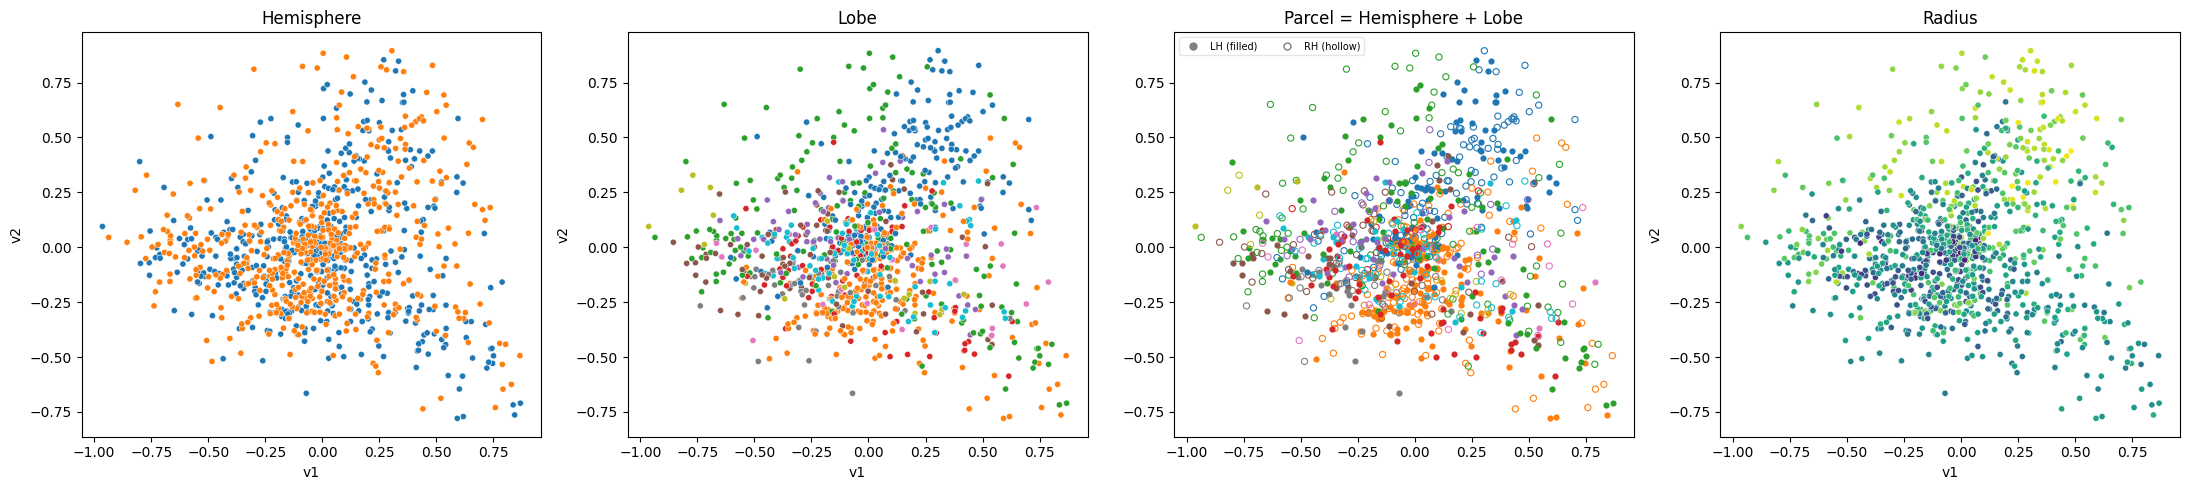

In [ ]:
s_size=20

lobes = data['region'].unique()
lobe_palette = dict(zip(lobes, sns.color_palette('tab10', len(lobes))))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1 - Hemisphere
sns.scatterplot(ax=axes[0], x='v1', y='v2', data=data,
                hue='hemisphere', palette='tab10', legend=False, s=s_size)
axes[0].set_title("Hemisphere")

# Plot 2 - Lobe
sns.scatterplot(ax=axes[1], x='v1', y='v2', data=data,
                hue='region', palette=lobe_palette, legend=False, s=s_size)
axes[1].set_title("Lobe")

# Plot 3 - Parcel (lobe color, filled=LH, hollow=RH)
ax = axes[2]
for lobe in lobes:
    color = lobe_palette[lobe]
    lobe_data = data[data['region'] == lobe]
    
    lh = lobe_data[lobe_data['hemisphere'] == 'LH']
    rh = lobe_data[lobe_data['hemisphere'] == 'RH']
    
    # Left hemisphere — filled markers
    if len(lh):
        ax.scatter(lh['v1'], lh['v2'], c=[color], s=s_size,
                   marker='o', linewidths=0)
    # Right hemisphere — hollow markers
    if len(rh):
        ax.scatter(rh['v1'], rh['v2'], facecolors='none', edgecolors=[color],
                   s=s_size, marker='o', linewidths=0.8)

# Legend: lobe colors
lobe_handles = [mpatches.Patch(color=lobe_palette[l], label=l) for l in lobes]
# Legend: hemisphere markers
lh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, label='LH (filled)')
rh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, markerfacecolor='none', label='RH (hollow)')
# ax.legend(handles=lobe_handles + [lh_handle, rh_handle],
#           fontsize=7, ncol=2, loc='best', framealpha=0.5)
ax.legend(handles=[lh_handle, rh_handle],
          fontsize=7, ncol=2, loc='best', framealpha=0.5)
axes[2].set_title("Parcel = Hemisphere + Lobe")

# Plot 4 - Radius
sns.scatterplot(ax=axes[3], x='v1', y='v2', data=data,
                hue='radius', palette='viridis', legend=False, s=s_size)
axes[3].set_title("Radius")

plt.tight_layout()
plt.savefig("pca.png")
plt.show()

experiment.update_files("pca.png")

#### UMAP

In [ ]:
import umap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

if scaling.value == 'std_time':
    x_mean = X.mean(axis=-1, keepdims=True)
    x_std = X.std(axis=-1, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_time':
    x_min = X.min(axis=-1, keepdims=True)
    x_max = X.max(axis=-1, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'std_parcels':
    x_mean = X.mean(axis=0, keepdims=True)
    x_std = X.std(axis=-0, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_parcels':
    x_min = X.min(axis=0, keepdims=True)
    x_max = X.max(axis=0, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'stf':
    x_mean = X.mean()
    x_std = X.std()
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax':
    x_min = X.min()
    x_max = X.max()
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value is None:
    X_scaled = X
else:
    raise ValueError("scaling can only be one of [std_time, minmax_time, std_parcels, minmax_parcels, std, minmax, None]")

n_neighbors = 500
reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors)
X_embed = reducer.fit_transform(X_scaled)
print(X_embed.shape)

data = pd.DataFrame()
data[['v1', 'v2']] = X_embed
data[y.columns] = y

data

(1000, 2)


,v1,v2,hemisphere,region,parcel,x,y,z,radius,season,episode,episode_split
0,-2.431136,12.207209,LH,Vis,LH_Vis,-36.200787,-35.877953,-24.405512,56.509765,1,2,a
1,-1.405837,11.719686,LH,Vis,LH_Vis,-35.961187,-51.102740,-18.938356,65.294397,1,2,a
2,-0.965285,11.981784,LH,Vis,LH_Vis,-26.340000,-45.000000,-14.560000,54.136764,1,2,a
3,-0.996447,11.945550,LH,Vis,LH_Vis,-29.790323,-63.064516,-12.387097,70.838102,1,2,a
4,-0.831494,12.060256,LH,Vis,LH_Vis,-31.905405,-43.148649,-8.581081,54.345154,1,2,a
...,...,...,...,...,...,...,...,...,...,...,...,...
995,-3.519492,10.791465,RH,DefaultpCunPCC,RH_DefaultpCunPCC,8.949541,-53.655963,37.316514,65.966498,1,2,a
996,-2.721408,10.644323,RH,DefaultpCunPCC,RH_DefaultpCunPCC,6.946809,-51.195035,45.187943,68.637745,1,2,a
997,-3.348318,10.897408,RH,DefaultpCunPCC,RH_DefaultpCunPCC,5.960606,-62.960606,44.796970,77.500550,1,2,a
998,-3.631459,15.113823,RH,ContpCun,RH_ContpCun,5.890805,-37.488506,40.350575,55.391863,1,2,a


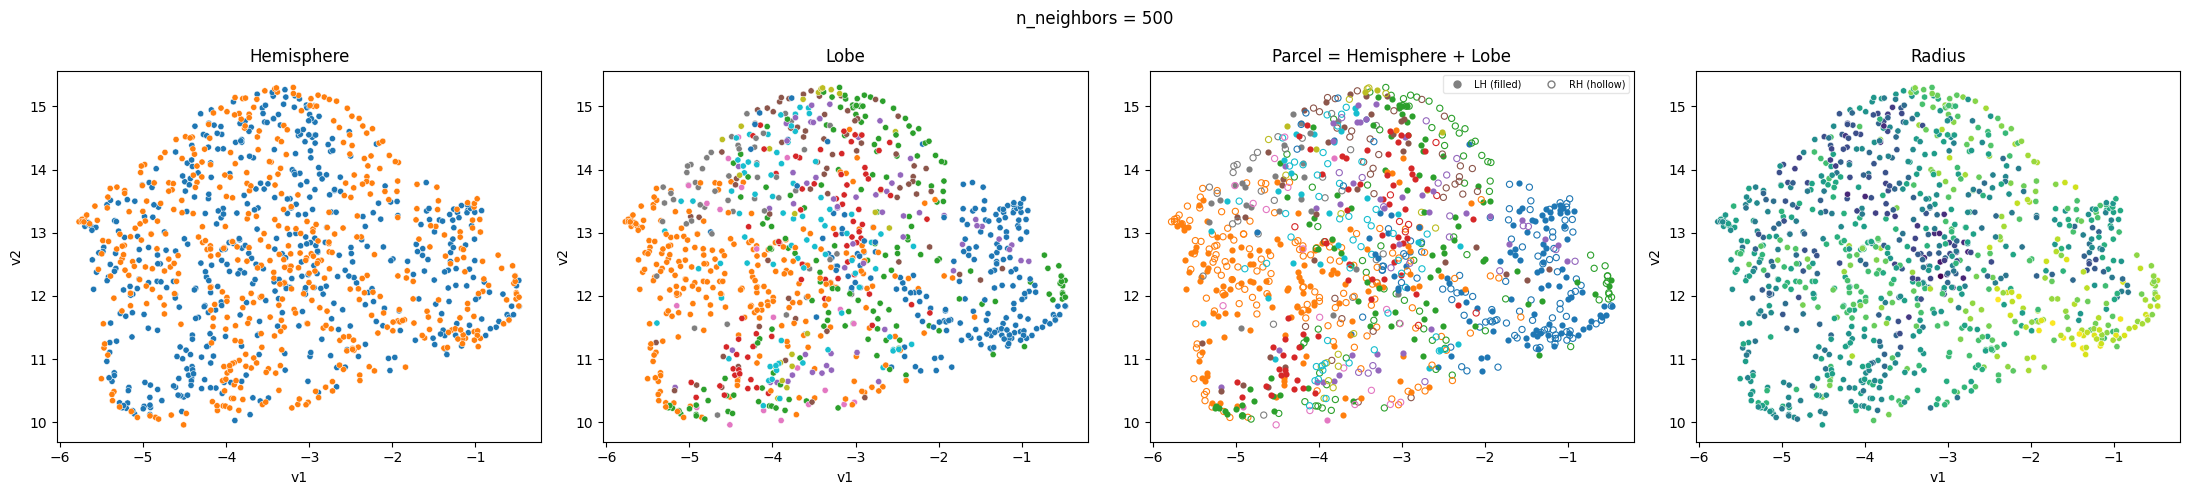

In [ ]:
s_size = 20

lobes = data['region'].unique()
lobe_palette = dict(zip(lobes, sns.color_palette('tab10', len(lobes))))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1 - Hemisphere
sns.scatterplot(ax=axes[0], x='v1', y='v2', data=data,
                hue='hemisphere', palette='tab10', legend=False, s=s_size)
axes[0].set_title("Hemisphere")

# Plot 2 - Lobe
sns.scatterplot(ax=axes[1], x='v1', y='v2', data=data,
                hue='region', palette=lobe_palette, legend=False, s=s_size)
axes[1].set_title("Lobe")

# Plot 3 - Parcel (lobe color, filled=LH, hollow=RH)
ax = axes[2]
for lobe in lobes:
    color = lobe_palette[lobe]
    lobe_data = data[data['region'] == lobe]
    
    lh = lobe_data[lobe_data['hemisphere'] == 'LH']
    rh = lobe_data[lobe_data['hemisphere'] == 'RH']
    
    # Left hemisphere — filled markers
    if len(lh):
        ax.scatter(lh['v1'], lh['v2'], c=[color], s=s_size,
                   marker='o', linewidths=0)
    # Right hemisphere — hollow markers
    if len(rh):
        ax.scatter(rh['v1'], rh['v2'], facecolors='none', edgecolors=[color],
                   s=s_size, marker='o', linewidths=0.8)

# Legend: lobe colors
lobe_handles = [mpatches.Patch(color=lobe_palette[l], label=l) for l in lobes]
# Legend: hemisphere markers
lh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, label='LH (filled)')
rh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, markerfacecolor='none', label='RH (hollow)')
# ax.legend(handles=lobe_handles + [lh_handle, rh_handle],
#           fontsize=7, ncol=2, loc='best', framealpha=0.5)
ax.legend(handles=[lh_handle, rh_handle],
          fontsize=7, ncol=2, loc='best', framealpha=0.5)
axes[2].set_title("Parcel = Hemisphere + Lobe")

# Plot 4 - Radius
sns.scatterplot(ax=axes[3], x='v1', y='v2', data=data,
                hue='radius', palette='viridis', legend=False, s=s_size)
axes[3].set_title("Radius")

fig.suptitle(f"n_neighbors = {n_neighbors}")
plt.tight_layout()
plt.savefig(f'UMAP@n_neighbors={n_neighbors}.png')
plt.show()

experiment.update_files(f'UMAP@n_neighbors={n_neighbors}.png')

#### t-SNE

In [ ]:
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

if scaling.value == 'std_time':
    x_mean = X.mean(axis=-1, keepdims=True)
    x_std = X.std(axis=-1, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_time':
    x_min = X.min(axis=-1, keepdims=True)
    x_max = X.max(axis=-1, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'std_parcels':
    x_mean = X.mean(axis=0, keepdims=True)
    x_std = X.std(axis=-0, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_parcels':
    x_min = X.min(axis=0, keepdims=True)
    x_max = X.max(axis=0, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'stf':
    x_mean = X.mean()
    x_std = X.std()
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax':
    x_min = X.min()
    x_max = X.max()
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value is None:
    X_scaled = X
else:
    raise ValueError("scaling can only be one of [std_time, minmax_time, std_parcels, minmax_parcels, std, minmax, None]")

perplexity = 500
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=43)
X_embed = tsne.fit_transform(X_scaled)
print(X_embed.shape)

data = pd.DataFrame()
data[['v1', 'v2']] = X_embed
data[y.columns] = y

data

(1000, 2)


,v1,v2,hemisphere,region,parcel,x,y,z,radius,season,episode,episode_split
0,0.202998,-0.573579,LH,Vis,LH_Vis,-36.200787,-35.877953,-24.405512,56.509765,1,2,a
1,1.281641,-1.588372,LH,Vis,LH_Vis,-35.961187,-51.102740,-18.938356,65.294397,1,2,a
2,0.985236,-2.268668,LH,Vis,LH_Vis,-26.340000,-45.000000,-14.560000,54.136764,1,2,a
3,1.045063,-1.997931,LH,Vis,LH_Vis,-29.790323,-63.064516,-12.387097,70.838102,1,2,a
4,0.902155,-2.205610,LH,Vis,LH_Vis,-31.905405,-43.148649,-8.581081,54.345154,1,2,a
...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.506100,0.365121,RH,DefaultpCunPCC,RH_DefaultpCunPCC,8.949541,-53.655963,37.316514,65.966498,1,2,a
996,2.061212,-0.473296,RH,DefaultpCunPCC,RH_DefaultpCunPCC,6.946809,-51.195035,45.187943,68.637745,1,2,a
997,1.222967,0.146686,RH,DefaultpCunPCC,RH_DefaultpCunPCC,5.960606,-62.960606,44.796970,77.500550,1,2,a
998,-2.624442,-0.492422,RH,ContpCun,RH_ContpCun,5.890805,-37.488506,40.350575,55.391863,1,2,a


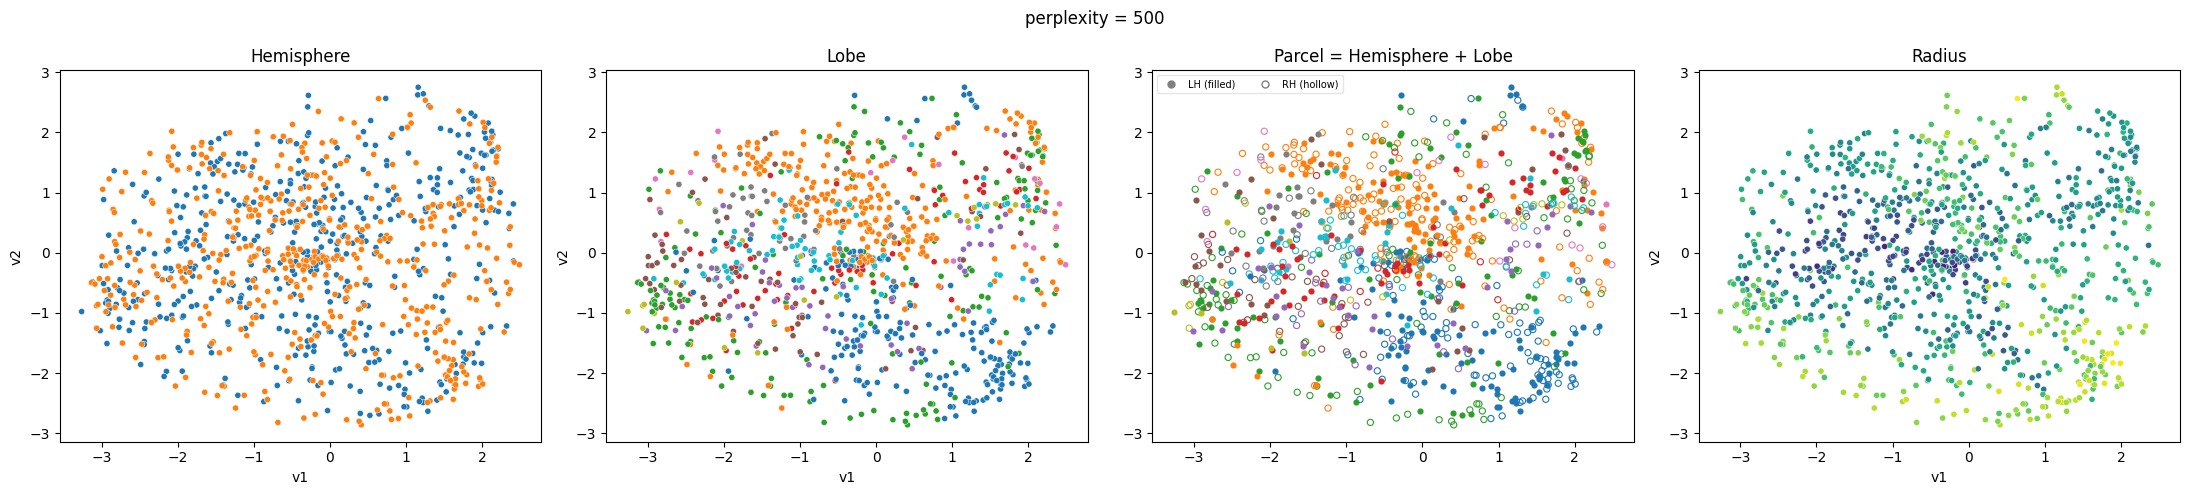

In [ ]:
s_size=20

lobes = data['region'].unique()
lobe_palette = dict(zip(lobes, sns.color_palette('tab10', len(lobes))))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1 - Hemisphere
sns.scatterplot(ax=axes[0], x='v1', y='v2', data=data,
                hue='hemisphere', palette='tab10', legend=False, s=s_size)
axes[0].set_title("Hemisphere")

# Plot 2 - Lobe
sns.scatterplot(ax=axes[1], x='v1', y='v2', data=data,
                hue='region', palette=lobe_palette, legend=False, s=s_size)
axes[1].set_title("Lobe")

# Plot 3 - Parcel (lobe color, filled=LH, hollow=RH)
ax = axes[2]
for lobe in lobes:
    color = lobe_palette[lobe]
    lobe_data = data[data['region'] == lobe]
    
    lh = lobe_data[lobe_data['hemisphere'] == 'LH']
    rh = lobe_data[lobe_data['hemisphere'] == 'RH']
    
    # Left hemisphere — filled markers
    if len(lh):
        ax.scatter(lh['v1'], lh['v2'], c=[color], s=s_size,
                   marker='o', linewidths=0)
    # Right hemisphere — hollow markers
    if len(rh):
        ax.scatter(rh['v1'], rh['v2'], facecolors='none', edgecolors=[color],
                   s=s_size, marker='o', linewidths=0.8)

# Legend: lobe colors
lobe_handles = [mpatches.Patch(color=lobe_palette[l], label=l) for l in lobes]
# Legend: hemisphere markers
lh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, label='LH (filled)')
rh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, markerfacecolor='none', label='RH (hollow)')
# ax.legend(handles=lobe_handles + [lh_handle, rh_handle],
#           fontsize=7, ncol=2, loc='best', framealpha=0.5)
ax.legend(handles=[lh_handle, rh_handle],
          fontsize=7, ncol=2, loc='best', framealpha=0.5)
axes[2].set_title("Parcel = Hemisphere + Lobe")

# Plot 4 - Radius
sns.scatterplot(ax=axes[3], x='v1', y='v2', data=data,
                hue='radius', palette='viridis', legend=False, s=s_size)
axes[3].set_title("Radius")

fig.suptitle(f"perplexity = {perplexity}")
plt.tight_layout()
plt.savefig(f'tSNE@perplexity={perplexity}.png')
plt.show()

experiment.update_files(f'tSNE@perplexity={perplexity}.png')

## HCPTRT Single Tasks

In [1]:
from utils import preprocessing
from utils.dataloader import HCPTRTLoader

import ipywidgets as widgets
from IPython.display import display
from utils.experiment_recorder import Experiment, Parameter

/home/petron/AIMS/Thesis/TRACE_Algonauts/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [3]:
subject =  widgets.Text(value='', placeholder='sub-01', description='Subject:')
task = widgets.Text(value='', placeholder='motor', description='Task:')
session =  widgets.Text(value='', placeholder='ses-001', description='Session')
run = widgets.IntSlider(value=1, min=1, max=10, step=1, description='Run:')
trials = widgets.Text(value='', placeholder='episodes', description='Trials Method:')
time_collapse = widgets.Text(value='', placeholder='windowed_mean', description='Time Collapse Approach')
pad_width = widgets.BoundedIntText(value=500, min=1, max=500, description='Pad Width')
n_windows = widgets.BoundedIntText(value=60, min=1, max=300, description='n_time_windows')
n_subsamples = widgets.BoundedIntText(value=4, min=1, max=300, description='n_time_subsamples')
n_episodes = widgets.BoundedIntText(value=1, min=1, max=300, description='n_episodes')

display(subject, task, session, run, trials)
display(time_collapse, pad_width, n_windows, n_subsamples, n_episodes)

experiment_name = widgets.Text(value='', placeholder='v1.0', description='Experiment Name:')
experiment_dir = widgets.Text(value='', placeholder='experiments', description='Folder:')
experiment_description = widgets.Text(value='', placeholder='start', description='Description:')
baseline = widgets.Text(value='', placeholder='v1.0', description='Baseline:')
messages = widgets.Text(value='', placeholder='', description='Messages:')

display(
    experiment_name, 
    experiment_dir, 
    experiment_description,
    baseline, 
    messages
)



Text(value='', description='Subject:', placeholder='sub-01')

Text(value='', description='Task:', placeholder='motor')

Text(value='', description='Session', placeholder='ses-001')

IntSlider(value=1, description='Run:', max=10, min=1)

Text(value='', description='Trials Method:', placeholder='episodes')

...

Text(value='', description='Experiment Name:', placeholder='v1.0')

Text(value='', description='Folder:', placeholder='experiments')

Text(value='', description='Description:', placeholder='start')

Text(value='', description='Baseline:', placeholder='v1.0')

Text(value='', description='Messages:', placeholder='')

In [74]:
experiment = Experiment(
    name=experiment_name.value,
    dir=experiment_dir.value,
    description=experiment_description.value,
    baseline=baseline.value
)
experiment.add_params([
    Parameter(subject.value, 'subject', 'Dataset_Parameters'),
    Parameter(trials.value, 'trials', 'Preprocessing_Parameters'),
    Parameter(time_collapse.value, 'time_collapse', 'Preprocessing_Parameters'),
    Parameter(pad_width.value, 'pad_width', 'Preprocessing_Parameters'),
    Parameter(n_windows.value, 'n_windows', 'Preprocessing_Parameters'),
    Parameter(n_subsamples.value, 'n_subsamples', 'Preprocessing_Parameters'),
    Parameter(n_episodes.value, 'n_episodes', 'Preprocessing_Parameter')
])
experiment.update_messages(messages.value)

In [75]:
print(experiment.name)

hcptrt_task_level_embedding


In [76]:
hcptrt_dataset = HCPTRTLoader(
    fmri_dir="data/cneuromod.processed/fmriprep/hcptrt/",
    subjects=[1],
    tr=1.49,
    hrf_delay=5,
    parcellation="mmp"
)

Parcellation : mmp — 379 regions (hcp_utils, no download needed)


In [77]:
X, y = preprocessing.parcel_samples(
    dataset=hcptrt_dataset,
    subject=subject.value,
    task=task.value,
    session=session.value,
    run=run.value,
    trials=trials.value,
    time_collapse=time_collapse.value,
    n_windows=n_windows.value
)

Loading hcptrt BOLD | sub-01 | task-wm


100%|██████████| 1/1 [00:03<00:00,  3.09s/it]

Loading parcel atlas info



/home/petron/AIMS/Thesis/TRACE_Algonauts/utils/loaders/hcptrt.py:388: RuntimeWarning: Mean of empty slice
  centroid = np.nanmean(all_coords[mask], axis=0)   # NaN-safe for subcortical


In [78]:
X.shape, y.shape

((379, 4), (379, 10))

In [79]:
y

,hemisphere,region,parcel,x,y,z,radius,session,run,task
0,LH,occipital,LH_occipital,37.434330,-55.626625,-12.058883,68.125374,1,1,wm
1,LH,parietal,LH_parietal,33.280323,-63.345737,36.170280,80.178246,1,1,wm
2,LH,occipital,LH_occipital,34.561161,-33.175758,-3.022521,48.002506,1,1,wm
3,LH,occipital,LH_occipital,37.780685,-49.741508,-13.152594,63.832508,1,1,wm
4,LH,occipital,LH_occipital,39.610821,-35.818512,-16.599998,55.924438,1,1,wm
...,...,...,...,...,...,...,...,...,...,...
374,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm
375,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm
376,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm
377,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm


In [80]:
scaling = widgets.Text(value='', placeholder='None', description='Scaling:')
display(scaling)

Text(value='', description='Scaling:', placeholder='None')

In [83]:
experiment.update_param(
    Parameter(scaling.value, 'scaling', 'Preprocessing_Parameters')
)

### Dimensionality Reduction

#### PCA

In [84]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

if scaling.value == 'std_time':
    x_mean = X.mean(axis=-1, keepdims=True)
    x_std = X.std(axis=-1, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_time':
    x_min = X.min(axis=-1, keepdims=True)
    x_max = X.max(axis=-1, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'std_parcels':
    x_mean = X.mean(axis=0, keepdims=True)
    x_std = X.std(axis=-0, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_parcels':
    x_min = X.min(axis=0, keepdims=True)
    x_max = X.max(axis=0, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'stf':
    x_mean = X.mean()
    x_std = X.std()
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax':
    x_min = X.min()
    x_max = X.max()
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value is None:
    X_scaled = X
else:
    raise ValueError("scaling can only be one of [std_time, minmax_time, std_parcels, minmax_parcels, std, minmax, None]")

reducer = PCA(n_components=2)
X_embed = reducer.fit_transform(X_scaled)
print(X_embed.shape)

data = pd.DataFrame()
data[['v1', 'v2']] = X_embed
data[y.columns] = y

data

(379, 2)


,v1,v2,hemisphere,region,parcel,x,y,z,radius,session,run,task
0,0.241131,0.511043,LH,occipital,LH_occipital,37.434330,-55.626625,-12.058883,68.125374,1,1,wm
1,0.219238,-0.325003,LH,parietal,LH_parietal,33.280323,-63.345737,36.170280,80.178246,1,1,wm
2,0.149513,0.458760,LH,occipital,LH_occipital,34.561161,-33.175758,-3.022521,48.002506,1,1,wm
3,-0.632374,0.542987,LH,occipital,LH_occipital,37.780685,-49.741508,-13.152594,63.832508,1,1,wm
4,-0.480611,0.338322,LH,occipital,LH_occipital,39.610821,-35.818512,-16.599998,55.924438,1,1,wm
...,...,...,...,...,...,...,...,...,...,...,...,...
374,-0.159137,-0.697678,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm
375,-0.724646,-0.378632,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm
376,0.474133,0.148562,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm
377,0.421470,0.070265,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm


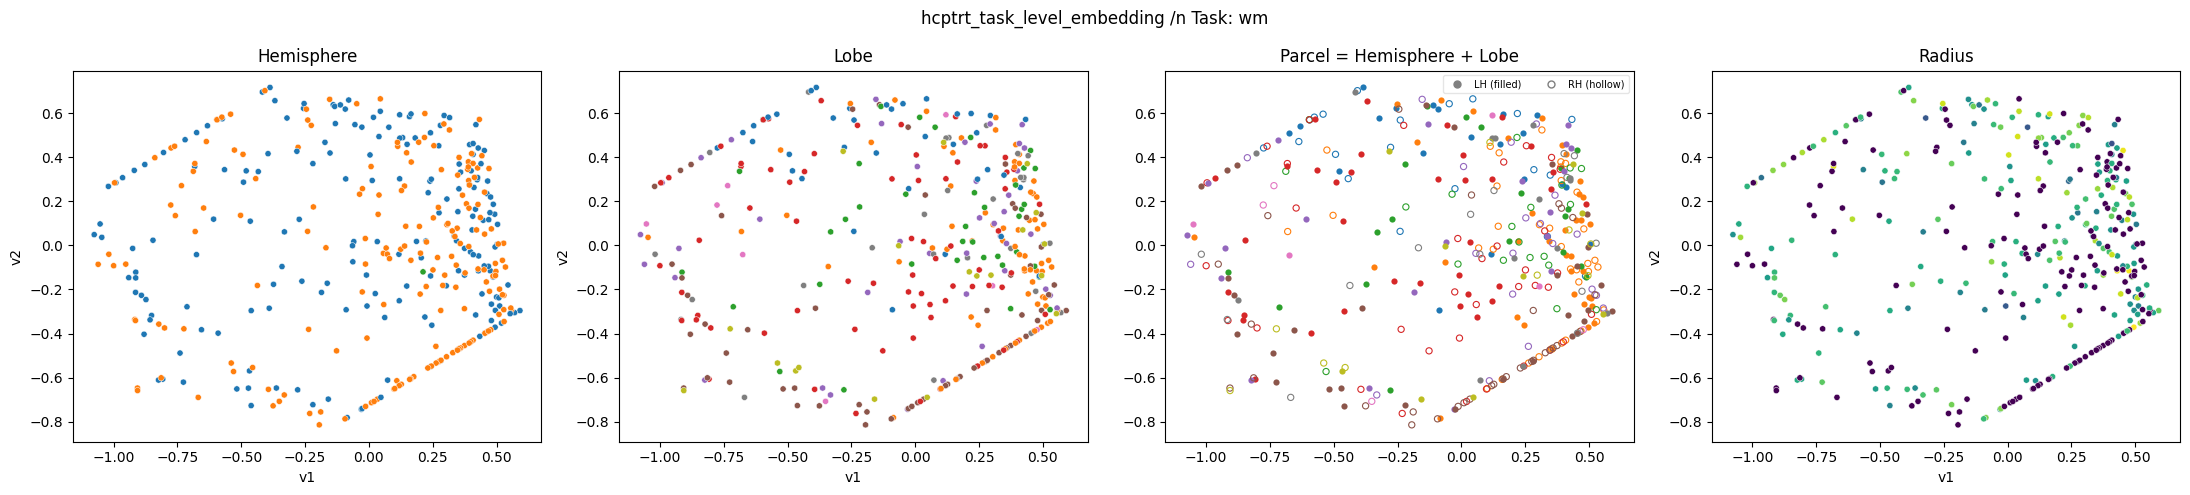

In [85]:
s_size=20

lobes = data['region'].unique()
lobe_palette = dict(zip(lobes, sns.color_palette('tab10', len(lobes))))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1 - Hemisphere
sns.scatterplot(ax=axes[0], x='v1', y='v2', data=data,
                hue='hemisphere', palette='tab10', legend=False, s=s_size)
axes[0].set_title("Hemisphere")

# Plot 2 - Lobe
sns.scatterplot(ax=axes[1], x='v1', y='v2', data=data,
                hue='region', palette=lobe_palette, legend=False, s=s_size)
axes[1].set_title("Lobe")

# Plot 3 - Parcel (lobe color, filled=LH, hollow=RH)
ax = axes[2]
for lobe in lobes:
    color = lobe_palette[lobe]
    lobe_data = data[data['region'] == lobe]
    
    lh = lobe_data[lobe_data['hemisphere'] == 'LH']
    rh = lobe_data[lobe_data['hemisphere'] == 'RH']
    
    # Left hemisphere — filled markers
    if len(lh):
        ax.scatter(lh['v1'], lh['v2'], c=[color], s=s_size,
                   marker='o', linewidths=0)
    # Right hemisphere — hollow markers
    if len(rh):
        ax.scatter(rh['v1'], rh['v2'], facecolors='none', edgecolors=[color],
                   s=s_size, marker='o', linewidths=0.8)

# Legend: lobe colors
lobe_handles = [mpatches.Patch(color=lobe_palette[l], label=l) for l in lobes]
# Legend: hemisphere markers
lh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, label='LH (filled)')
rh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, markerfacecolor='none', label='RH (hollow)')
# ax.legend(handles=lobe_handles + [lh_handle, rh_handle],
#           fontsize=7, ncol=2, loc='best', framealpha=0.5)
ax.legend(handles=[lh_handle, rh_handle],
          fontsize=7, ncol=2, loc='best', framealpha=0.5)
axes[2].set_title("Parcel = Hemisphere + Lobe")

# Plot 4 - Radius
sns.scatterplot(ax=axes[3], x='v1', y='v2', data=data,
                hue='radius', palette='viridis', legend=False, s=s_size)
axes[3].set_title("Radius")

fig.suptitle(f"{experiment.name} /n Task: {task.value}")
plt.tight_layout()
plt.savefig(f"pca_{task.value}.png")
plt.show()

experiment.update_files(f"pca_{task.value}.png")

#### UMAP

In [98]:
import umap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

if scaling.value == 'std_time':
    x_mean = X.mean(axis=-1, keepdims=True)
    x_std = X.std(axis=-1, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_time':
    x_min = X.min(axis=-1, keepdims=True)
    x_max = X.max(axis=-1, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'std_parcels':
    x_mean = X.mean(axis=0, keepdims=True)
    x_std = X.std(axis=-0, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_parcels':
    x_min = X.min(axis=0, keepdims=True)
    x_max = X.max(axis=0, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'stf':
    x_mean = X.mean()
    x_std = X.std()
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax':
    x_min = X.min()
    x_max = X.max()
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value is None:
    X_scaled = X
else:
    raise ValueError("scaling can only be one of [std_time, minmax_time, std_parcels, minmax_parcels, std, minmax, None]")

n_neighbors = 500
reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors)
X_embed = reducer.fit_transform(X_scaled)
print(X_embed.shape)

data = pd.DataFrame()
data[['v1', 'v2']] = X_embed
data[y.columns] = y

data

/home/petron/AIMS/Thesis/TRACE_Algonauts/.venv/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


(379, 2)


,v1,v2,hemisphere,region,parcel,x,y,z,radius,session,run,task
0,-1.763813,1.577667,LH,occipital,LH_occipital,37.434330,-55.626625,-12.058883,68.125374,1,1,wm
1,-3.436976,3.685890,LH,parietal,LH_parietal,33.280323,-63.345737,36.170280,80.178246,1,1,wm
2,-1.681997,1.942852,LH,occipital,LH_occipital,34.561161,-33.175758,-3.022521,48.002506,1,1,wm
3,0.245895,2.216449,LH,occipital,LH_occipital,37.780685,-49.741508,-13.152594,63.832508,1,1,wm
4,-0.551085,2.877452,LH,occipital,LH_occipital,39.610821,-35.818512,-16.599998,55.924438,1,1,wm
...,...,...,...,...,...,...,...,...,...,...,...,...
374,-1.827177,4.981967,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm
375,-0.310194,4.683983,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm
376,-3.481406,1.893624,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm
377,-3.501521,2.236098,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm


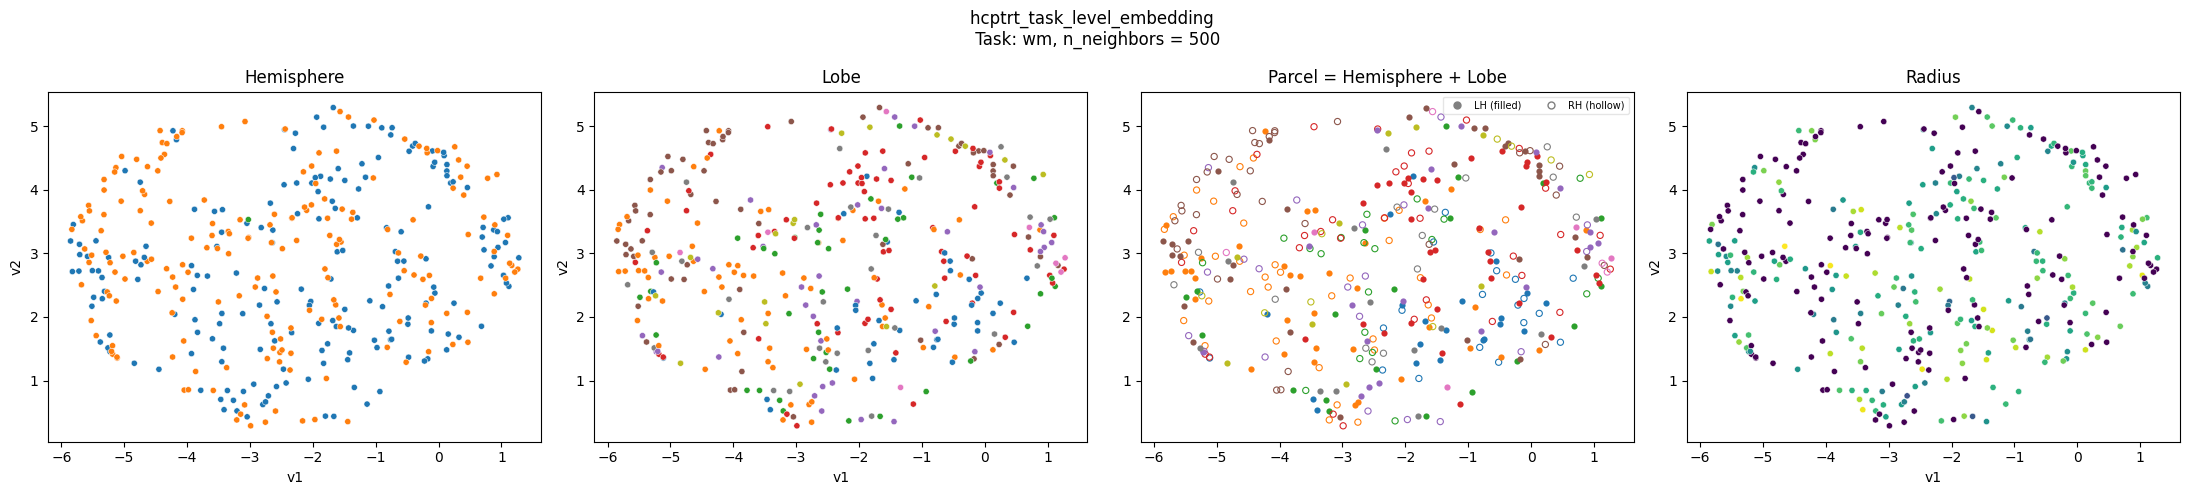

In [99]:
s_size = 20

lobes = data['region'].unique()
lobe_palette = dict(zip(lobes, sns.color_palette('tab10', len(lobes))))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1 - Hemisphere
sns.scatterplot(ax=axes[0], x='v1', y='v2', data=data,
                hue='hemisphere', palette='tab10', legend=False, s=s_size)
axes[0].set_title("Hemisphere")

# Plot 2 - Lobe
sns.scatterplot(ax=axes[1], x='v1', y='v2', data=data,
                hue='region', palette=lobe_palette, legend=False, s=s_size)
axes[1].set_title("Lobe")

# Plot 3 - Parcel (lobe color, filled=LH, hollow=RH)
ax = axes[2]
for lobe in lobes:
    color = lobe_palette[lobe]
    lobe_data = data[data['region'] == lobe]
    
    lh = lobe_data[lobe_data['hemisphere'] == 'LH']
    rh = lobe_data[lobe_data['hemisphere'] == 'RH']
    
    # Left hemisphere — filled markers
    if len(lh):
        ax.scatter(lh['v1'], lh['v2'], c=[color], s=s_size,
                   marker='o', linewidths=0)
    # Right hemisphere — hollow markers
    if len(rh):
        ax.scatter(rh['v1'], rh['v2'], facecolors='none', edgecolors=[color],
                   s=s_size, marker='o', linewidths=0.8)

# Legend: lobe colors
lobe_handles = [mpatches.Patch(color=lobe_palette[l], label=l) for l in lobes]
# Legend: hemisphere markers
lh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, label='LH (filled)')
rh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, markerfacecolor='none', label='RH (hollow)')
# ax.legend(handles=lobe_handles + [lh_handle, rh_handle],
#           fontsize=7, ncol=2, loc='best', framealpha=0.5)
ax.legend(handles=[lh_handle, rh_handle],
          fontsize=7, ncol=2, loc='best', framealpha=0.5)
axes[2].set_title("Parcel = Hemisphere + Lobe")

# Plot 4 - Radius
sns.scatterplot(ax=axes[3], x='v1', y='v2', data=data,
                hue='radius', palette='viridis', legend=False, s=s_size)
axes[3].set_title("Radius")


fig.suptitle(f"{experiment.name} \n Task: {task.value}, n_neighbors = {n_neighbors}")
plt.tight_layout()
plt.savefig(f'UMAP_{task.value}@n_neighbors={n_neighbors}.png')
plt.show()

experiment.update_files(f'UMAP_{task.value}@n_neighbors={n_neighbors}.png')

#### t-SNE

In [110]:
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

if scaling.value == 'std_time':
    x_mean = X.mean(axis=-1, keepdims=True)
    x_std = X.std(axis=-1, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_time':
    x_min = X.min(axis=-1, keepdims=True)
    x_max = X.max(axis=-1, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'std_parcels':
    x_mean = X.mean(axis=0, keepdims=True)
    x_std = X.std(axis=-0, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_parcels':
    x_min = X.min(axis=0, keepdims=True)
    x_max = X.max(axis=0, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'stf':
    x_mean = X.mean()
    x_std = X.std()
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax':
    x_min = X.min()
    x_max = X.max()
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value is None:
    X_scaled = X
else:
    raise ValueError("scaling can only be one of [std_time, minmax_time, std_parcels, minmax_parcels, std, minmax, None]")

perplexity = 250
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=43)
X_embed = tsne.fit_transform(X_scaled)
print(X_embed.shape)

data = pd.DataFrame()
data[['v1', 'v2']] = X_embed
data[y.columns] = y

data

(379, 2)


,v1,v2,hemisphere,region,parcel,x,y,z,radius,session,run,task
0,1.473742,-1.885383,LH,occipital,LH_occipital,37.434330,-55.626625,-12.058883,68.125374,1,1,wm
1,1.775290,0.145385,LH,parietal,LH_parietal,33.280323,-63.345737,36.170280,80.178246,1,1,wm
2,1.260440,-1.679545,LH,occipital,LH_occipital,34.561161,-33.175758,-3.022521,48.002506,1,1,wm
3,-0.511476,-1.897710,LH,occipital,LH_occipital,37.780685,-49.741508,-13.152594,63.832508,1,1,wm
4,0.043324,-1.063663,LH,occipital,LH_occipital,39.610821,-35.818512,-16.599998,55.924438,1,1,wm
...,...,...,...,...,...,...,...,...,...,...,...,...
374,0.942883,0.909756,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm
375,-0.438683,0.383741,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm
376,2.366439,-1.165762,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm
377,2.261127,-0.959575,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,1,1,wm


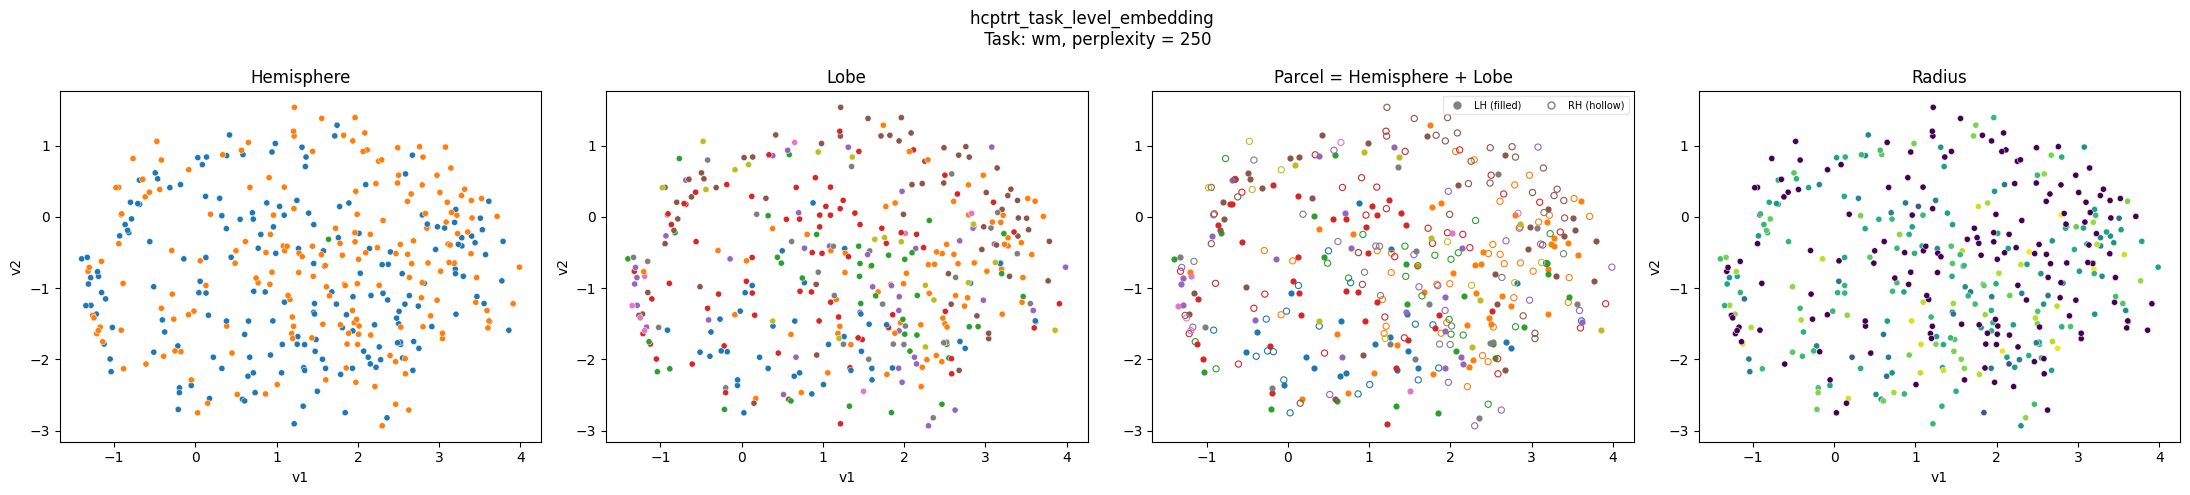

In [111]:
s_size=20

lobes = data['region'].unique()
lobe_palette = dict(zip(lobes, sns.color_palette('tab10', len(lobes))))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1 - Hemisphere
sns.scatterplot(ax=axes[0], x='v1', y='v2', data=data,
                hue='hemisphere', palette='tab10', legend=False, s=s_size)
axes[0].set_title("Hemisphere")

# Plot 2 - Lobe
sns.scatterplot(ax=axes[1], x='v1', y='v2', data=data,
                hue='region', palette=lobe_palette, legend=False, s=s_size)
axes[1].set_title("Lobe")

# Plot 3 - Parcel (lobe color, filled=LH, hollow=RH)
ax = axes[2]
for lobe in lobes:
    color = lobe_palette[lobe]
    lobe_data = data[data['region'] == lobe]
    
    lh = lobe_data[lobe_data['hemisphere'] == 'LH']
    rh = lobe_data[lobe_data['hemisphere'] == 'RH']
    
    # Left hemisphere — filled markers
    if len(lh):
        ax.scatter(lh['v1'], lh['v2'], c=[color], s=s_size,
                   marker='o', linewidths=0)
    # Right hemisphere — hollow markers
    if len(rh):
        ax.scatter(rh['v1'], rh['v2'], facecolors='none', edgecolors=[color],
                   s=s_size, marker='o', linewidths=0.8)

# Legend: lobe colors
lobe_handles = [mpatches.Patch(color=lobe_palette[l], label=l) for l in lobes]
# Legend: hemisphere markers
lh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, label='LH (filled)')
rh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, markerfacecolor='none', label='RH (hollow)')
# ax.legend(handles=lobe_handles + [lh_handle, rh_handle],
#           fontsize=7, ncol=2, loc='best', framealpha=0.5)
ax.legend(handles=[lh_handle, rh_handle],
          fontsize=7, ncol=2, loc='best', framealpha=0.5)
axes[2].set_title("Parcel = Hemisphere + Lobe")

# Plot 4 - Radius
sns.scatterplot(ax=axes[3], x='v1', y='v2', data=data,
                hue='radius', palette='viridis', legend=False, s=s_size)
axes[3].set_title("Radius")

fig.suptitle(f"{experiment.name} \n Task: {task.value}, perplexity = {perplexity}")
plt.tight_layout()
plt.savefig(f'tSNE_{task.value}@perplexity={perplexity}.png')
plt.show()

experiment.update_files(f'tSNE_{task.value}@perplexity={perplexity}.png')

## HCPTRT Across Tasks

In [1]:
import numpy as np
import pandas as pd

from utils import preprocessing
from utils.dataloader import HCPTRTLoader

import ipywidgets as widgets
from IPython.display import display
from utils.experiment_recorder import Experiment, Parameter

/home/petron/AIMS/Thesis/TRACE_Algonauts/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [2]:
subject =  widgets.Text(value='', placeholder='sub-01', description='Subject:')
session =  widgets.Text(value='', placeholder='ses-001', description='Session')
run = widgets.IntSlider(value=1, min=1, max=10, step=1, description='Run:')
trials = widgets.Text(value='', placeholder='episodes', description='Trials Method:')
time_collapse = widgets.Text(value='', placeholder='windowed_mean', description='Time Collapse Approach')
pad_width = widgets.BoundedIntText(value=500, min=1, max=500, description='Pad Width')
n_windows = widgets.BoundedIntText(value=60, min=1, max=300, description='n_time_windows')
n_subsamples = widgets.BoundedIntText(value=4, min=1, max=300, description='n_time_subsamples')
n_episodes = widgets.BoundedIntText(value=1, min=1, max=300, description='n_episodes')

display(subject, session, run, trials)
display(time_collapse, pad_width, n_windows, n_subsamples, n_episodes)

experiment_name = widgets.Text(value='', placeholder='v1.0', description='Experiment Name:')
experiment_dir = widgets.Text(value='', placeholder='experiments', description='Folder:')
experiment_description = widgets.Text(value='', placeholder='start', description='Description:')
baseline = widgets.Text(value='', placeholder='v1.0', description='Baseline:')
messages = widgets.Text(value='', placeholder='', description='Messages:')

display(
    experiment_name, 
    experiment_dir, 
    experiment_description,
    baseline, 
    messages
)



Text(value='', description='Subject:', placeholder='sub-01')

Text(value='', description='Session', placeholder='ses-001')

IntSlider(value=1, description='Run:', max=10, min=1)

Text(value='', description='Trials Method:', placeholder='episodes')

Text(value='', description='Time Collapse Approach', placeholder='windowed_mean')

...

Text(value='', description='Experiment Name:', placeholder='v1.0')

Text(value='', description='Folder:', placeholder='experiments')

Text(value='', description='Description:', placeholder='start')

Text(value='', description='Baseline:', placeholder='v1.0')

Text(value='', description='Messages:', placeholder='')

In [3]:
experiment = Experiment(
    name=experiment_name.value,
    dir=experiment_dir.value,
    description=experiment_description.value,
    baseline=baseline.value
)
experiment.add_params([
    Parameter(subject.value, 'subject', 'Dataset_Parameters'),
    Parameter(trials.value, 'trials', 'Preprocessing_Parameters'),
    Parameter(time_collapse.value, 'time_collapse', 'Preprocessing_Parameters'),
    Parameter(pad_width.value, 'pad_width', 'Preprocessing_Parameters'),
    Parameter(n_windows.value, 'n_windows', 'Preprocessing_Parameters'),
    Parameter(n_subsamples.value, 'n_subsamples', 'Preprocessing_Parameters'),
    Parameter(n_episodes.value, 'n_episodes', 'Preprocessing_Parameter')
])
experiment.update_messages(messages.value)

In [4]:
print(experiment.name)

hcptrt_across_tasks


In [5]:
hcptrt_dataset = HCPTRTLoader(
    fmri_dir="data/cneuromod.processed/fmriprep/hcptrt/",
    subjects=[1],
    tr=1.49,
    hrf_delay=5,
    parcellation="mmp"
)

Parcellation : mmp — 379 regions (hcp_utils, no download needed)


In [7]:
X = []
y = pd.DataFrame()

ses_001_tasks = ['motor', 'gambling', 'wm', 'restingstate', 'social']
ses_002_tasks = ['emotion', 'language', 'relational']

for task in  ses_001_tasks + ses_002_tasks:
    if task in ses_001_tasks:
        session = 'ses-001'
    else:
        session = 'ses-002'

    x, Y = preprocessing.parcel_samples(
        dataset=hcptrt_dataset,
        subject=subject.value,
        task=task,
        session=session,
        run=run.value,
        trials=trials.value,
        time_collapse=time_collapse.value,
        n_windows=n_windows.value
    )
    print(x.shape, Y.shape)

    X.append(x)
    # y = pd.concat([y, Y], axis=0, ignore_index=True)

X = np.hstack(X)
y = Y


Loading hcptrt BOLD | sub-01 | task-motor


100%|██████████| 1/1 [00:02<00:00,  2.15s/it]
/home/petron/AIMS/Thesis/TRACE_Algonauts/utils/loaders/hcptrt.py:387: RuntimeWarning: Mean of empty slice
  centroid = np.nanmean(all_coords[mask], axis=0)   # NaN-safe for subcortical


Loading parcel atlas info
(379, 60) (379, 10)
Loading hcptrt BOLD | sub-01 | task-gambling


100%|██████████| 1/1 [00:01<00:00,  1.90s/it]
/home/petron/AIMS/Thesis/TRACE_Algonauts/utils/loaders/hcptrt.py:387: RuntimeWarning: Mean of empty slice
  centroid = np.nanmean(all_coords[mask], axis=0)   # NaN-safe for subcortical


Loading parcel atlas info
(379, 60) (379, 10)
Loading hcptrt BOLD | sub-01 | task-wm


...

100%|██████████| 1/1 [00:01<00:00,  1.96s/it]
/home/petron/AIMS/Thesis/TRACE_Algonauts/utils/loaders/hcptrt.py:387: RuntimeWarning: Mean of empty slice
  centroid = np.nanmean(all_coords[mask], axis=0)   # NaN-safe for subcortical


Loading parcel atlas info
(379, 60) (379, 10)
Loading hcptrt BOLD | sub-01 | task-relational


100%|██████████| 1/1 [00:01<00:00,  1.61s/it]

Loading parcel atlas info
(379, 60) (379, 10)



/home/petron/AIMS/Thesis/TRACE_Algonauts/utils/loaders/hcptrt.py:387: RuntimeWarning: Mean of empty slice
  centroid = np.nanmean(all_coords[mask], axis=0)   # NaN-safe for subcortical


In [8]:
X.shape, y.shape

((379, 480), (379, 10))

In [9]:
y

,hemisphere,region,parcel,x,y,z,radius,session,run,task
0,LH,occipital,LH_occipital,37.434330,-55.626625,-12.058883,68.125374,2,1,relational
1,LH,parietal,LH_parietal,33.280323,-63.345737,36.170280,80.178246,2,1,relational
2,LH,occipital,LH_occipital,34.561161,-33.175758,-3.022521,48.002506,2,1,relational
3,LH,occipital,LH_occipital,37.780685,-49.741508,-13.152594,63.832508,2,1,relational
4,LH,occipital,LH_occipital,39.610821,-35.818512,-16.599998,55.924438,2,1,relational
...,...,...,...,...,...,...,...,...,...,...
374,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational
375,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational
376,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational
377,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational


In [11]:
scaling = widgets.Text(value='', placeholder='None', description='Scaling:')
display(scaling)

Text(value='', description='Scaling:', placeholder='None')

In [15]:
experiment.update_param(
    Parameter(scaling.value, 'scaling', 'Preprocessing_Parameters')
)

### Dimensionality Reduction

#### PCA

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

if scaling.value == 'std_time':
    x_mean = X.mean(axis=-1, keepdims=True)
    x_std = X.std(axis=-1, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_time':
    x_min = X.min(axis=-1, keepdims=True)
    x_max = X.max(axis=-1, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'std_parcels':
    x_mean = X.mean(axis=0, keepdims=True)
    x_std = X.std(axis=-0, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_parcels':
    x_min = X.min(axis=0, keepdims=True)
    x_max = X.max(axis=0, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'stf':
    x_mean = X.mean()
    x_std = X.std()
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax':
    x_min = X.min()
    x_max = X.max()
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == "None":
    X_scaled = X
else:
    raise ValueError("scaling can only be one of [std_time, minmax_time, std_parcels, minmax_parcels, std, minmax, None]")

reducer = PCA(n_components=2)
X_embed = reducer.fit_transform(X_scaled)
print(X_embed.shape)

data = pd.DataFrame()
data[['v1', 'v2']] = X_embed
data[y.columns] = y

data

(379, 2)


,v1,v2,hemisphere,region,parcel,x,y,z,radius,session,run,task
0,-11.012014,-1.750705,LH,occipital,LH_occipital,37.434330,-55.626625,-12.058883,68.125374,2,1,relational
1,-11.017997,11.143000,LH,parietal,LH_parietal,33.280323,-63.345737,36.170280,80.178246,2,1,relational
2,1.091219,7.225587,LH,occipital,LH_occipital,34.561161,-33.175758,-3.022521,48.002506,2,1,relational
3,-12.748021,3.126135,LH,occipital,LH_occipital,37.780685,-49.741508,-13.152594,63.832508,2,1,relational
4,-10.671424,2.521742,LH,occipital,LH_occipital,39.610821,-35.818512,-16.599998,55.924438,2,1,relational
...,...,...,...,...,...,...,...,...,...,...,...,...
374,2.203843,0.261231,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational
375,2.656139,-0.046499,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational
376,3.756991,0.336793,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational
377,3.301049,-0.185249,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational


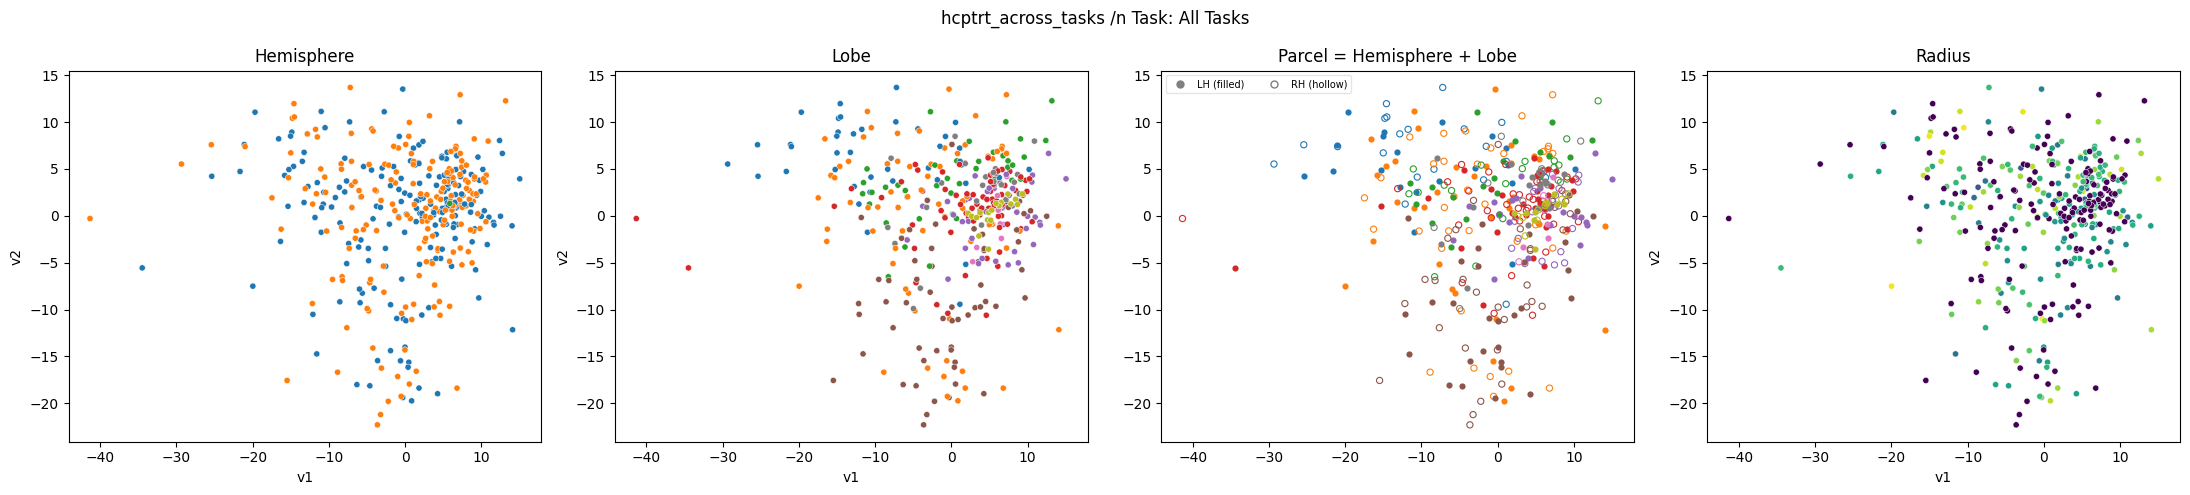

In [17]:
s_size=20

lobes = data['region'].unique()
lobe_palette = dict(zip(lobes, sns.color_palette('tab10', len(lobes))))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1 - Hemisphere
sns.scatterplot(ax=axes[0], x='v1', y='v2', data=data,
                hue='hemisphere', palette='tab10', legend=False, s=s_size)
axes[0].set_title("Hemisphere")

# Plot 2 - Lobe
sns.scatterplot(ax=axes[1], x='v1', y='v2', data=data,
                hue='region', palette=lobe_palette, legend=False, s=s_size)
axes[1].set_title("Lobe")

# Plot 3 - Parcel (lobe color, filled=LH, hollow=RH)
ax = axes[2]
for lobe in lobes:
    color = lobe_palette[lobe]
    lobe_data = data[data['region'] == lobe]
    
    lh = lobe_data[lobe_data['hemisphere'] == 'LH']
    rh = lobe_data[lobe_data['hemisphere'] == 'RH']
    
    # Left hemisphere — filled markers
    if len(lh):
        ax.scatter(lh['v1'], lh['v2'], c=[color], s=s_size,
                   marker='o', linewidths=0)
    # Right hemisphere — hollow markers
    if len(rh):
        ax.scatter(rh['v1'], rh['v2'], facecolors='none', edgecolors=[color],
                   s=s_size, marker='o', linewidths=0.8)

# Legend: lobe colors
lobe_handles = [mpatches.Patch(color=lobe_palette[l], label=l) for l in lobes]
# Legend: hemisphere markers
lh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, label='LH (filled)')
rh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, markerfacecolor='none', label='RH (hollow)')
# ax.legend(handles=lobe_handles + [lh_handle, rh_handle],
#           fontsize=7, ncol=2, loc='best', framealpha=0.5)
ax.legend(handles=[lh_handle, rh_handle],
          fontsize=7, ncol=2, loc='best', framealpha=0.5)
axes[2].set_title("Parcel = Hemisphere + Lobe")

# Plot 4 - Radius
sns.scatterplot(ax=axes[3], x='v1', y='v2', data=data,
                hue='radius', palette='viridis', legend=False, s=s_size)
axes[3].set_title("Radius")

fig.suptitle(f"{experiment.name} /n Task: All Tasks")
plt.tight_layout()
plt.savefig(f"pca_all_tasks.png")
plt.show()

experiment.update_files(f"pca_all_tasks.png")

#### UMAP

In [22]:
import umap
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

if scaling.value == 'std_time':
    x_mean = X.mean(axis=-1, keepdims=True)
    x_std = X.std(axis=-1, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_time':
    x_min = X.min(axis=-1, keepdims=True)
    x_max = X.max(axis=-1, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'std_parcels':
    x_mean = X.mean(axis=0, keepdims=True)
    x_std = X.std(axis=-0, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_parcels':
    x_min = X.min(axis=0, keepdims=True)
    x_max = X.max(axis=0, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'stf':
    x_mean = X.mean()
    x_std = X.std()
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax':
    x_min = X.min()
    x_max = X.max()
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == "None":
    X_scaled = X
else:
    raise ValueError("scaling can only be one of [std_time, minmax_time, std_parcels, minmax_parcels, std, minmax, None]")

n_neighbors = 15
reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors)
X_embed = reducer.fit_transform(X_scaled)
print(X_embed.shape)

data = pd.DataFrame()
data[['v1', 'v2']] = X_embed
data[y.columns] = y

data

(379, 2)


,v1,v2,hemisphere,region,parcel,x,y,z,radius,session,run,task
0,8.423879,6.092016,LH,occipital,LH_occipital,37.434330,-55.626625,-12.058883,68.125374,2,1,relational
1,7.758511,7.565222,LH,parietal,LH_parietal,33.280323,-63.345737,36.170280,80.178246,2,1,relational
2,8.990571,7.426359,LH,occipital,LH_occipital,34.561161,-33.175758,-3.022521,48.002506,2,1,relational
3,8.403558,6.091402,LH,occipital,LH_occipital,37.780685,-49.741508,-13.152594,63.832508,2,1,relational
4,8.522724,6.277522,LH,occipital,LH_occipital,39.610821,-35.818512,-16.599998,55.924438,2,1,relational
...,...,...,...,...,...,...,...,...,...,...,...,...
374,11.940074,9.559038,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational
375,12.048754,9.455352,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational
376,12.920918,9.620609,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational
377,12.493800,9.626397,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational


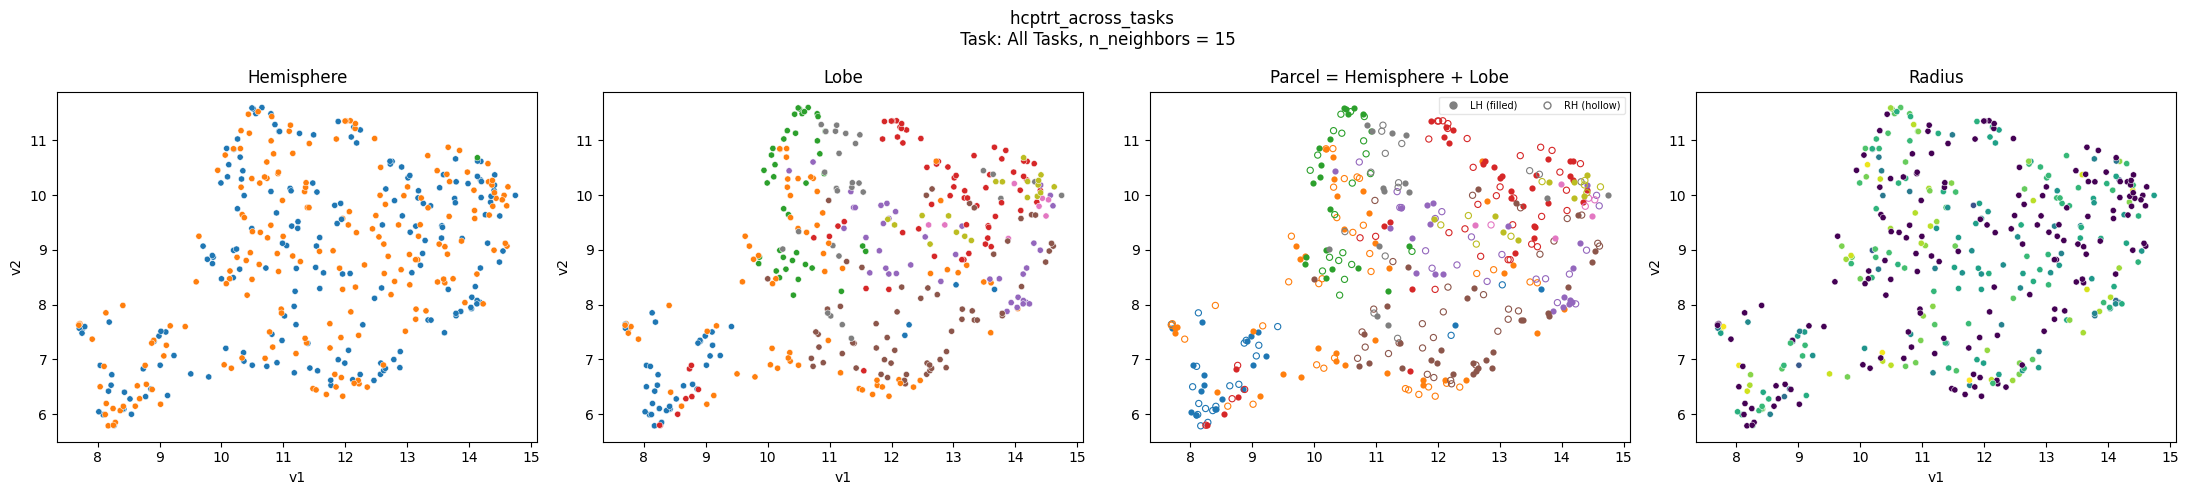

In [23]:
s_size = 20

lobes = data['region'].unique()
lobe_palette = dict(zip(lobes, sns.color_palette('tab10', len(lobes))))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1 - Hemisphere
sns.scatterplot(ax=axes[0], x='v1', y='v2', data=data,
                hue='hemisphere', palette='tab10', legend=False, s=s_size)
axes[0].set_title("Hemisphere")

# Plot 2 - Lobe
sns.scatterplot(ax=axes[1], x='v1', y='v2', data=data,
                hue='region', palette=lobe_palette, legend=False, s=s_size)
axes[1].set_title("Lobe")

# Plot 3 - Parcel (lobe color, filled=LH, hollow=RH)
ax = axes[2]
for lobe in lobes:
    color = lobe_palette[lobe]
    lobe_data = data[data['region'] == lobe]
    
    lh = lobe_data[lobe_data['hemisphere'] == 'LH']
    rh = lobe_data[lobe_data['hemisphere'] == 'RH']
    
    # Left hemisphere — filled markers
    if len(lh):
        ax.scatter(lh['v1'], lh['v2'], c=[color], s=s_size,
                   marker='o', linewidths=0)
    # Right hemisphere — hollow markers
    if len(rh):
        ax.scatter(rh['v1'], rh['v2'], facecolors='none', edgecolors=[color],
                   s=s_size, marker='o', linewidths=0.8)

# Legend: lobe colors
lobe_handles = [mpatches.Patch(color=lobe_palette[l], label=l) for l in lobes]
# Legend: hemisphere markers
lh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, label='LH (filled)')
rh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, markerfacecolor='none', label='RH (hollow)')
# ax.legend(handles=lobe_handles + [lh_handle, rh_handle],
#           fontsize=7, ncol=2, loc='best', framealpha=0.5)
ax.legend(handles=[lh_handle, rh_handle],
          fontsize=7, ncol=2, loc='best', framealpha=0.5)
axes[2].set_title("Parcel = Hemisphere + Lobe")

# Plot 4 - Radius
sns.scatterplot(ax=axes[3], x='v1', y='v2', data=data,
                hue='radius', palette='viridis', legend=False, s=s_size)
axes[3].set_title("Radius")


fig.suptitle(f"{experiment.name} \n Task: All Tasks, n_neighbors = {n_neighbors}")
plt.tight_layout()
plt.savefig(f'UMAP_all_tasks@n_neighbors={n_neighbors}.png')
plt.show()

experiment.update_files(f'UMAP_all_tasks@n_neighbors={n_neighbors}.png')

#### t-SNE

In [28]:
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

if scaling.value == 'std_time':
    x_mean = X.mean(axis=-1, keepdims=True)
    x_std = X.std(axis=-1, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_time':
    x_min = X.min(axis=-1, keepdims=True)
    x_max = X.max(axis=-1, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'std_parcels':
    x_mean = X.mean(axis=0, keepdims=True)
    x_std = X.std(axis=-0, keepdims=True)
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax_parcels':
    x_min = X.min(axis=0, keepdims=True)
    x_max = X.max(axis=0, keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == 'stf':
    x_mean = X.mean()
    x_std = X.std()
    X_scaled = (X - x_mean) / (x_std)
elif scaling.value == 'minmax':
    x_min = X.min()
    x_max = X.max()
    X_scaled = (X - x_min) / (x_max - x_min)
elif scaling.value == "None":
    X_scaled = X
else:
    raise ValueError("scaling can only be one of [std_time, minmax_time, std_parcels, minmax_parcels, std, minmax, None]")

perplexity = 15
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=43)
X_embed = tsne.fit_transform(X_scaled)
print(X_embed.shape)

data = pd.DataFrame()
data[['v1', 'v2']] = X_embed
data[y.columns] = y

data

(379, 2)


,v1,v2,hemisphere,region,parcel,x,y,z,radius,session,run,task
0,-37.819576,5.407859,LH,occipital,LH_occipital,37.434330,-55.626625,-12.058883,68.125374,2,1,relational
1,-25.803825,3.974728,LH,parietal,LH_parietal,33.280323,-63.345737,36.170280,80.178246,2,1,relational
2,-33.209087,14.714187,LH,occipital,LH_occipital,34.561161,-33.175758,-3.022521,48.002506,2,1,relational
3,-36.621433,4.451090,LH,occipital,LH_occipital,37.780685,-49.741508,-13.152594,63.832508,2,1,relational
4,-35.895775,3.828578,LH,occipital,LH_occipital,39.610821,-35.818512,-16.599998,55.924438,2,1,relational
...,...,...,...,...,...,...,...,...,...,...,...,...
374,2.940707,2.852267,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational
375,2.539470,2.677679,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational
376,9.111799,2.817584,LH,subcortical,LH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational
377,8.421110,2.592552,RH,subcortical,RH_subcortical,0.000000,0.000000,0.000000,0.000000,2,1,relational


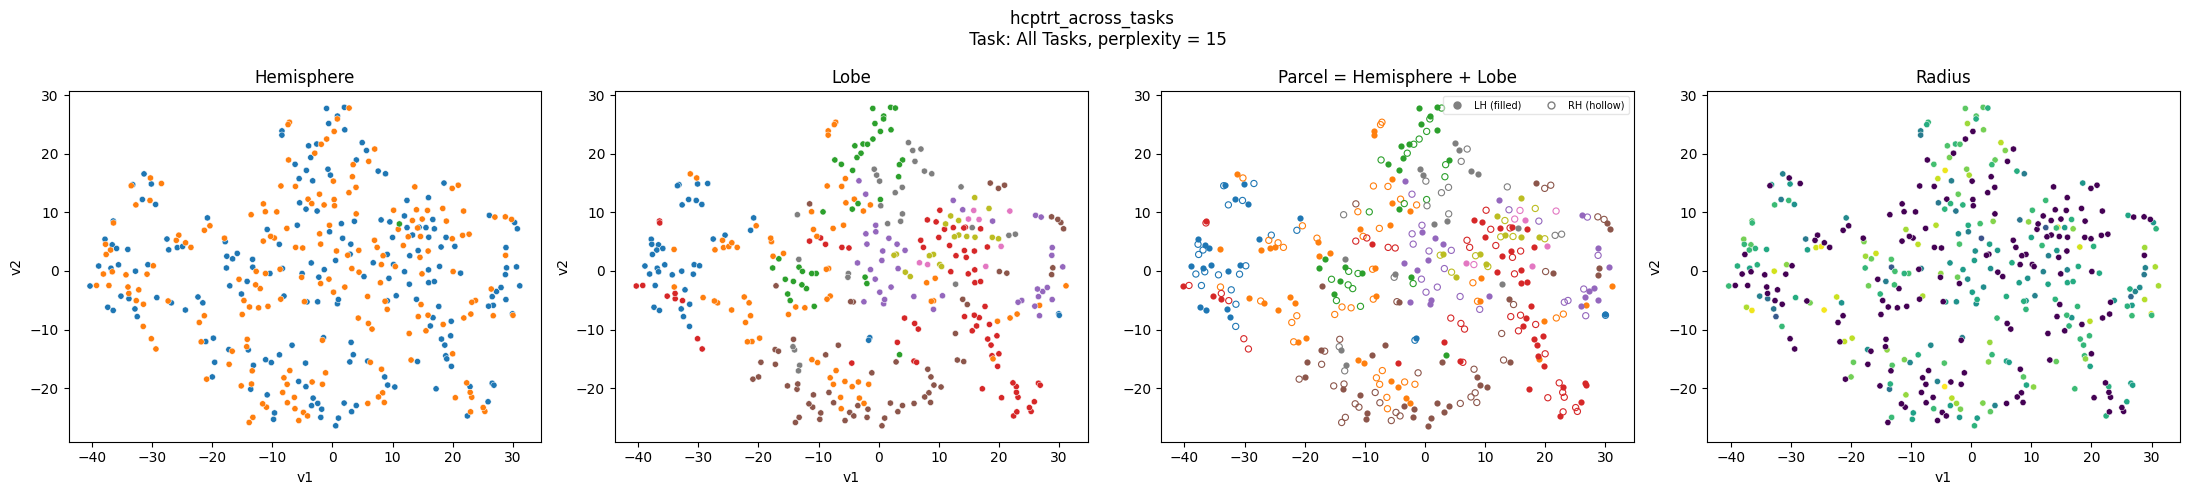

In [29]:
s_size=20

lobes = data['region'].unique()
lobe_palette = dict(zip(lobes, sns.color_palette('tab10', len(lobes))))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1 - Hemisphere
sns.scatterplot(ax=axes[0], x='v1', y='v2', data=data,
                hue='hemisphere', palette='tab10', legend=False, s=s_size)
axes[0].set_title("Hemisphere")

# Plot 2 - Lobe
sns.scatterplot(ax=axes[1], x='v1', y='v2', data=data,
                hue='region', palette=lobe_palette, legend=False, s=s_size)
axes[1].set_title("Lobe")

# Plot 3 - Parcel (lobe color, filled=LH, hollow=RH)
ax = axes[2]
for lobe in lobes:
    color = lobe_palette[lobe]
    lobe_data = data[data['region'] == lobe]
    
    lh = lobe_data[lobe_data['hemisphere'] == 'LH']
    rh = lobe_data[lobe_data['hemisphere'] == 'RH']
    
    # Left hemisphere — filled markers
    if len(lh):
        ax.scatter(lh['v1'], lh['v2'], c=[color], s=s_size,
                   marker='o', linewidths=0)
    # Right hemisphere — hollow markers
    if len(rh):
        ax.scatter(rh['v1'], rh['v2'], facecolors='none', edgecolors=[color],
                   s=s_size, marker='o', linewidths=0.8)

# Legend: lobe colors
lobe_handles = [mpatches.Patch(color=lobe_palette[l], label=l) for l in lobes]
# Legend: hemisphere markers
lh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, label='LH (filled)')
rh_handle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='None',
                        markersize=5, markerfacecolor='none', label='RH (hollow)')
# ax.legend(handles=lobe_handles + [lh_handle, rh_handle],
#           fontsize=7, ncol=2, loc='best', framealpha=0.5)
ax.legend(handles=[lh_handle, rh_handle],
          fontsize=7, ncol=2, loc='best', framealpha=0.5)
axes[2].set_title("Parcel = Hemisphere + Lobe")

# Plot 4 - Radius
sns.scatterplot(ax=axes[3], x='v1', y='v2', data=data,
                hue='radius', palette='viridis', legend=False, s=s_size)
axes[3].set_title("Radius")

fig.suptitle(f"{experiment.name} \n Task: All Tasks, perplexity = {perplexity}")
plt.tight_layout()
plt.savefig(f'tSNE_all_tasks@perplexity={perplexity}.png')
plt.show()

experiment.update_files(f'tSNE_all_tasks@perplexity={perplexity}.png')

# Save Experiment   

In [30]:
# import os

# png_files = [f for f in os.listdir() if f.endswith('.png')]
# print(png_files)
# experiment.update_files(png_files)

In [31]:
experiment.save()

Model saved to experiments/hcptrt_across_tasks


In [87]:
! rm *.png